<a href="https://colab.research.google.com/github/YanoObed/Obadia/blob/main/Untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [2]:
# Upload dataset (in Colab)
from google.colab import files
uploaded = files.upload()

Saving data (4).csv to data (4).csv


In [3]:
# Load dataset
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

In [4]:
# Clean dataset
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.dropna(inplace=True)

/tmp/ipython-input-4-2210351906.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


In [5]:
# Encode target
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])


In [6]:
# Features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [7]:
# Dataset info
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns\n")
display(df.head())

Dataset: 569 rows, 32 columns



,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
# Feature importance with Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)
feat_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)


In [9]:
# Top 10 features
top10 = feat_importances.head(10).index.tolist()
print("Top 10 features:")
display(feat_importances.head(10))

Top 10 features:


,0
area_worst,0.130888
radius_worst,0.127435
concave points_worst,0.115075
perimeter_worst,0.108887
concave points_mean,0.098230
perimeter_mean,0.048581
concavity_worst,0.048050
concavity_mean,0.047817
area_mean,0.046152
area_se,0.041656


In [10]:
# Random combos: top5, last5, mixed
top5 = feat_importances.head(5).index.tolist()
last5 = feat_importances.tail(5).index.tolist()

import random
combo1 = top5
combo2 = last5
combo3 = random.sample(top5, 3) + random.sample(last5, 2)

print(f"Feature combos:\nTop 5: {combo1}\nLast 5: {combo2}\nMixed: {combo3}")


Feature combos:
Top 5: ['area_worst', 'radius_worst', 'concave points_worst', 'perimeter_worst', 'concave points_mean']
Last 5: ['compactness_se', 'symmetry_se', 'fractal_dimension_mean', 'concave points_se', 'smoothness_se']
Mixed: ['radius_worst', 'area_worst', 'perimeter_worst', 'concave points_se', 'fractal_dimension_mean']


In [11]:
# Evaluate combos
def eval_combo(features):
    X_sub = X[features]
    X_train, X_test, y_train, y_test = train_test_split(X_sub, y, test_size=0.2, random_state=42)
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return {
        "Accuracy": accuracy_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds)
    }

results = {
    "Top 5 Features": eval_combo(combo1),
    "Last 5 Features": eval_combo(combo2),
    "Mixed Features": eval_combo(combo3)
}
results_df = pd.DataFrame(results).T

In [12]:
print("\nFeature Combo Performance:")
display(results_df)


Feature Combo Performance:


,Accuracy,Recall,Precision,F1 Score
Top 5 Features,0.956140,0.930233,0.952381,0.941176
Last 5 Features,0.807018,0.674419,0.783784,0.725000
Mixed Features,0.964912,0.906977,1.000000,0.951220


In [13]:
# Train final model on top 10
X_top10 = X[top10]
X_train, X_test, y_train, y_test = train_test_split(X_top10, y, test_size=0.2, random_state=42)
final_rf = RandomForestClassifier(random_state=42)
final_rf.fit(X_train, y_train)
y_pred = final_rf.predict(X_test)

In [14]:
# Metrics final
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred)
}

In [15]:
perf_df = pd.DataFrame(metrics, index=["Score"])
print("\nFinal model performance on top 10 features:")
display(perf_df)


Final model performance on top 10 features:


,Accuracy,Recall,Precision,F1 Score
Score,0.95614,0.930233,0.952381,0.941176


In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

/tmp/ipython-input-17-2020537082.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importances.head(10), y=feat_importances.head(10).index, palette='viridis')


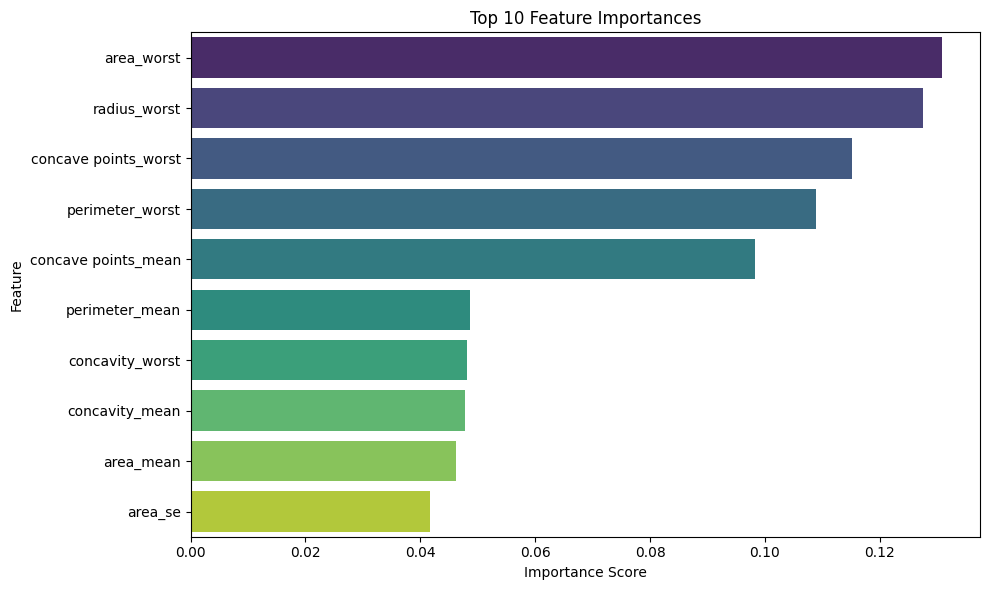

In [17]:
# 1. Bar plot of top 10 feature importances
plt.figure(figsize=(10,6))
sns.barplot(x=feat_importances.head(10), y=feat_importances.head(10).index, palette='viridis')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

/tmp/ipython-input-18-154736392.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['Accuracy'], palette='coolwarm')


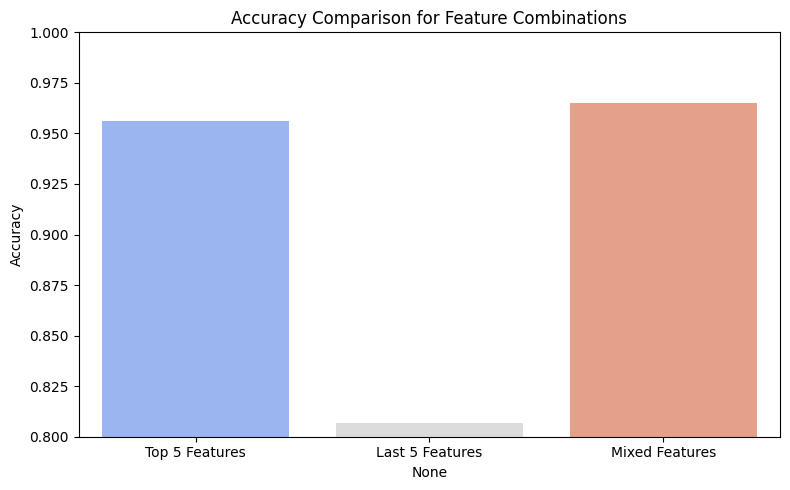

In [18]:
# 2. Bar plot comparing Accuracy of combos
plt.figure(figsize=(8,5))
sns.barplot(x=results_df.index, y=results_df['Accuracy'], palette='coolwarm')
plt.title('Accuracy Comparison for Feature Combinations')
plt.ylabel('Accuracy')
plt.ylim(0.8,1)
plt.tight_layout()
plt.show()

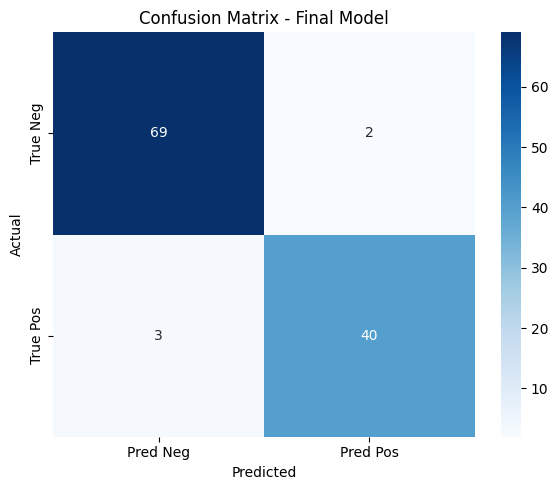

In [19]:
# 3. Confusion Matrix heatmap for final model
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Neg','Pred Pos'], yticklabels=['True Neg','True Pos'])
plt.title('Confusion Matrix - Final Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

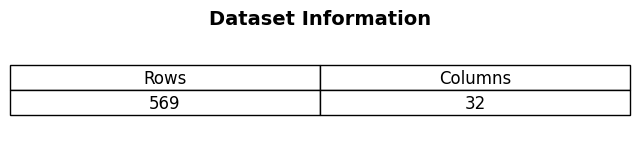

In [23]:
# Dataset info table
dataset_info = pd.DataFrame({"Rows": [df.shape[0]], "Columns": [df.shape[1]]})
plot_table(dataset_info, "Dataset Information")

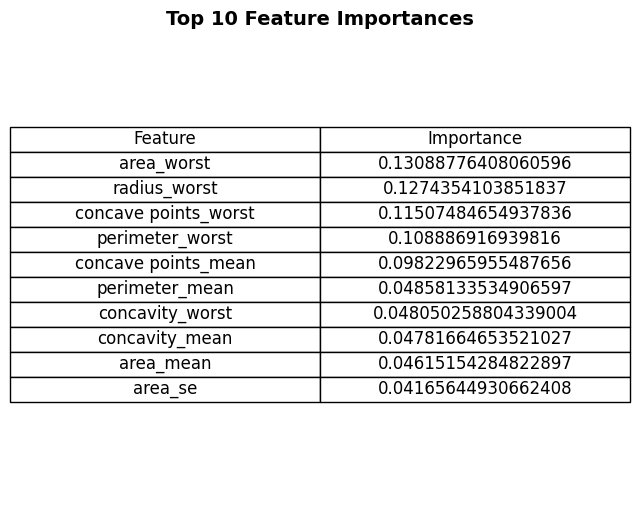

In [24]:
# Top 10 features importance table
top10_table = feat_importances.head(10).reset_index()
top10_table.columns = ['Feature', 'Importance']
plot_table(top10_table, "Top 10 Feature Importances")

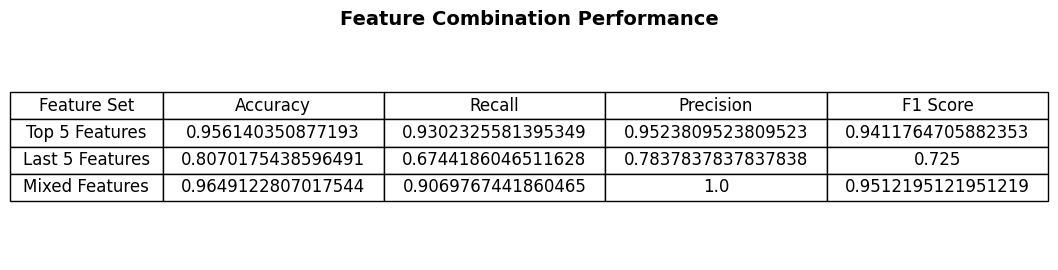

In [28]:
# Feature combo performance table
plot_table(results_df.reset_index().rename(columns={'index': 'Feature Set'}), "Feature Combination Performance")

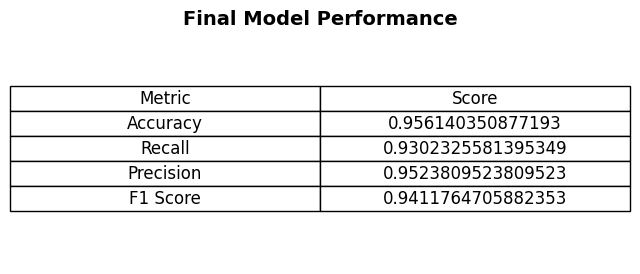

In [26]:
# Final model performance table
plot_table(perf_df.T.reset_index().rename(columns={'index':'Metric', 0:'Score'}), "Final Model Performance")
